`conda activate r_env_standr`

In [ ]:
library(reshape2)
library(Seurat)
library(ggplot2)
library(dplyr)
library(scales)
library(corrplot)
library(dittoSeq)
library(ggpubr)
library(SCpubr)
library(rstatix)
library(tidyverse)
library(RColorBrewer)
library(reticulate)
source("scripts/custom_magma.R")
source("scripts/robust_nmf_programs.R")   

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:base’:

    intersect



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


corrplot 0.92 loaded





── SCpubr 2.0.0.9000 ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

ℹ Have a look at extensive tutorials in SCpubr's book.

✔ If you use SCpubr in your research, please cite it accordingly.

★ If the package is useful to you, consider leaving a Star in the GitHub repository.

! Keep track of the package updates on Twitter (@Enblacar) or in the Official NEWS website.

♥ Happy plotting!



── Package version ──

CRAN:           2.0.2
Installed: 2.0.0.9000

⚠ There is a new version available onCRAN!




In [ ]:
myeloid <- readRDS('/projects/0/einf2548/cruiz/dmg/data/myeloid_rna.rds')
myeloid

An object of class Seurat 
19248 features across 60672 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
MP_list = readRDS('data/robust_NMF_programs_myeloid_nomt_noribo.rds')

In [ ]:
for (i in 1:ncol(MP_list)) {
  gene_set <- as.data.frame(MP_list)[[i]]
  myeloid <- UCell::AddModuleScore_UCell(
    obj = myeloid,
    features = list(gene_set),
    ncores = 16,
    name = colnames(MP_list)[i]
  )
}

In [ ]:
colnames(myeloid@meta.data %>% select(starts_with("signature")))

[1] "signature_1MP_1"  "signature_1MP_2"  "signature_1MP_3"  "signature_1MP_4" 
 [5] "signature_1MP_5"  "signature_1MP_6"  "signature_1MP_7"  "signature_1MP_8" 
 [9] "signature_1MP_9"  "signature_1MP_10" "signature_1MP_11" "signature_1MP_12"
[13] "signature_1MP_13"

In [ ]:
myeloid$Material <- recode(myeloid$Batch_for_correction,
                          '10Xv1_nuclei_multiome' = 'nuclei',
                           '10Xv3_cell_rna'='cell',
                           '10Xv3_nuclei_rna'='nuclei',
                           '10Xv3.1_nuclei_rna'='nuclei')

# due to diffenreces in cell vs nuclei discussed in the supplemental methods, we restricted this analysis to nuclei data
myeloid_subset = subset(myeloid, Material == 'nuclei')

In [ ]:
mg <- list(MP_list[,10])

bdm <- list('BDM'=c('CTSD','F13A1', 'TGFBI', 'ITGA4', 'CD163', 'MRC1', 'SELENOP','GPNMB', 'LGALS3'))

myeloid_subset <- AddModuleScore(
    object = myeloid_subset,
    features = c(bdm,mg),
    name = c('BDM', 'MG'))

Warning message:
“The following features are not present in the object: C11ORF65, not searching for symbol synonyms”


In [ ]:
# Extracting the scores
scores <- FetchData(
  myeloid_subset,
  vars = c('BDM1', 'MG2')
)

In [ ]:
# as suggested in https://doi.org/10.1038/s41588-023-01570-0
# Normalize scores by subtracting the mean score for each MP
normalized_scores <- apply(scores, 2, function(x) x - mean(x))
                           
# Function to determine the assignment of each cell
assign_to_MP <- function(score_row) {
  sorted_scores <- sort(score_row, decreasing = TRUE)
  top_score <- sorted_scores[1]
  second_score <- sorted_scores[2]

  if (second_score <= 0.95 * top_score) {
    return(names(sorted_scores)[1])
  } else {
    return("unresolved")
  }
}

# Apply the function to each row (cell)
cell_assignments <- apply(normalized_scores, 1, assign_to_MP)

In [ ]:
myeloid_subset$TAM <- cell_assignments

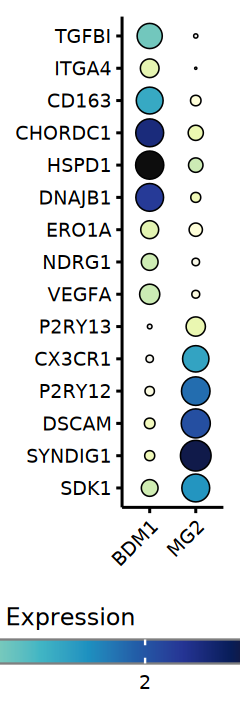

In [ ]:
options(repr.plot.height = 6, repr.plot.width = 2)
SCpubr::do_DotPlot(sample = subset(myeloid_subset, TAM!='unresolved'), group.by = 'TAM',
                   flip = TRUE,
                        features = rev(c('TGFBI', 'ITGA4', 'CD163',
                                        'CHORDC1', 'HSPD1','DNAJB1',
                                        'ERO1A', 'NDRG1', 'VEGFA',
                                         'P2RY13', 'CX3CR1','P2RY12',
                                        'DSCAM', 'SYNDIG1', 'SDK1')), 
                        dot.scale = 8)

In [ ]:
ggsave('figures/dotplot_mg_vs_bdm_markers.pdf', height = 6, width = 2)

In [ ]:
cluster_cols <- c("BDM1" = "#95bbcd",
                 "MG2"= '#343682')

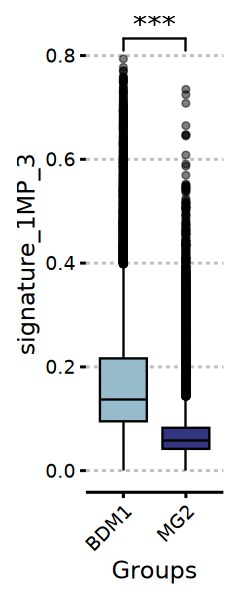

In [ ]:
options(repr.plot.height = 5, repr.plot.width = 2)
SCpubr::do_BoxPlot(sample = subset(myeloid_subset, TAM!='unresolved'),
                   colors.use = cluster_cols,
                   feature = "signature_1MP_3",
                   group.by = "TAM",
                   use_test = TRUE,
                    comparisons = list(c("BDM1", "MG2")),
                   map_signif_level = TRUE,
                   order = TRUE)

In [ ]:
ggsave('figures/boxplot_mg_vs_bdm_MP3_scoring.pdf', height = 5, width = 2)

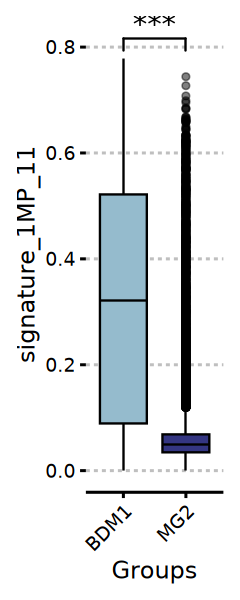

In [ ]:
SCpubr::do_BoxPlot(sample = subset(myeloid_subset, TAM!='unresolved'),
                   colors.use = cluster_cols,
                   feature = "signature_1MP_11",
                   group.by = "TAM",
                   use_test = TRUE,
                    comparisons = list(c("BDM1", "MG2")),
                   map_signif_level = TRUE,
                   order = TRUE)

In [ ]:
ggsave('figures/boxplot_mg_vs_bdm_MP11_scoring.pdf', height = 5, width = 2)

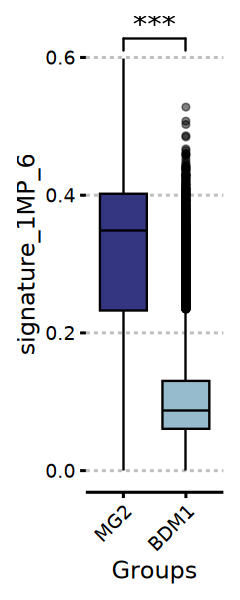

In [ ]:
SCpubr::do_BoxPlot(sample = subset(myeloid_subset, TAM!='unresolved'),
                   colors.use = cluster_cols,
                   feature = "signature_1MP_6",
                   group.by = "TAM",
                   use_test = TRUE,
                    comparisons = list(c("BDM1", "MG2")),
                   map_signif_level = TRUE,
                   order = TRUE)

In [ ]:
ggsave('figures/boxplot_mg_vs_bdm_MP6_scoring.pdf', height = 5, width = 2)

In [ ]:
cluster_cols <- c("BDM1" = "#95bbcd",
                 "MG2"= '#343682')

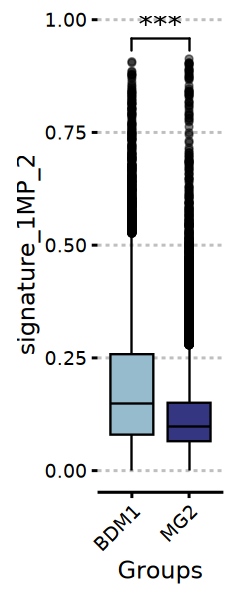

In [ ]:
options(repr.plot.height = 5, repr.plot.width = 2)
SCpubr::do_BoxPlot(sample = subset(myeloid_subset, TAM!='unresolved'),
                   colors.use = cluster_cols,
                   feature = "signature_1MP_2",
                   group.by = "TAM",
                   use_test = TRUE,
                    comparisons = list(c("BDM1", "MG2")),
                   map_signif_level = TRUE,
                   order = TRUE)

In [ ]:
ggsave('figures/boxplot_mg_vs_bdm_MP2_scoring.pdf', height = 4, width = 2)

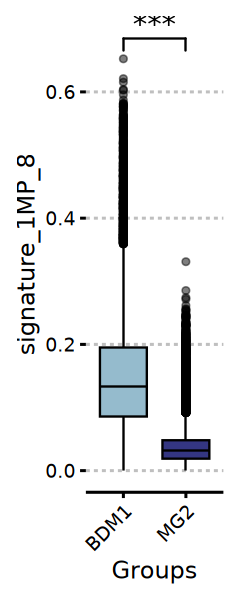

In [ ]:
SCpubr::do_BoxPlot(sample = subset(myeloid_subset, TAM!='unresolved'),
                   colors.use = cluster_cols,
                   feature = "signature_1MP_8",
                   group.by = "TAM",
                   use_test = TRUE,
                    comparisons = list(c("BDM1", "MG2")),
                   map_signif_level = TRUE,
                   order = TRUE)

In [ ]:
ggsave('figures/boxplot_mg_vs_bdm_MP8_scoring.pdf', height = 4, width = 2)

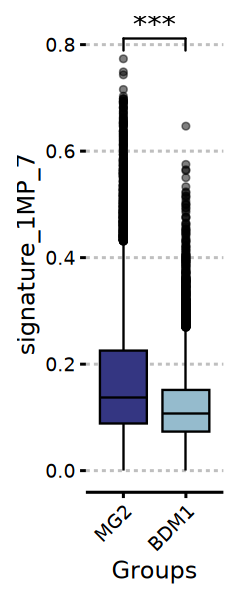

In [ ]:
SCpubr::do_BoxPlot(sample = subset(myeloid_subset, TAM!='unresolved'),
                   colors.use = cluster_cols,
                   feature = "signature_1MP_7",
                   group.by = "TAM",
                   use_test = TRUE,
                    comparisons = list(c("BDM1", "MG2")),
                   map_signif_level = TRUE,
                   order = TRUE)

In [ ]:
ggsave('figures/boxplot_mg_vs_bdm_MP7_scoring.pdf', height = 4, width = 2)

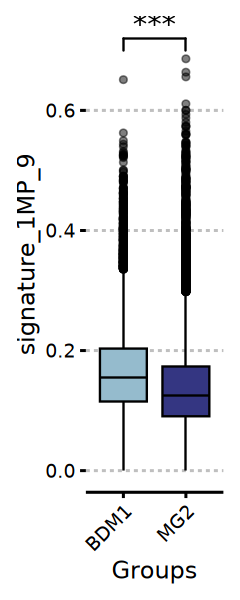

In [ ]:
SCpubr::do_BoxPlot(sample = subset(myeloid_subset, TAM!='unresolved'),
                   colors.use = cluster_cols,
                   feature = "signature_1MP_9",
                   group.by = "TAM",
                   use_test = TRUE,
                    comparisons = list(c("BDM1", "MG2")),
                   map_signif_level = TRUE,
                   order = TRUE)

In [ ]:
ggsave('figures/boxplot_mg_vs_bdm_MP9_scoring.pdf', height = 4, width = 2)